# PCD Assignment 02: Image Enhancement

**Course:** Pengolahan Citra Digital  
**Name:** Renata Ayu Sekar Kumala (25/557585/PA/23428)

## Objective

This notebook demonstrates image enhancement for four image conditions: dark, overly bright, low-contrast, and blurred. A photograph uploaded by the user serves as the reference image. Four degraded versions are created from it, enhanced with suitable methods, and compared with the reference using Peak Signal-to-Noise Ratio (PSNR).

The degradation is simulated so that the reference is known. Results from this controlled experiment should not be interpreted as expected performance on arbitrary photographs.

## 1. Import Libraries and Prepare Folders

Pillow is used for image processing, NumPy for numerical calculations, and Matplotlib for visualization. The `images` folder stores the reference and degraded images, the `results` folder stores enhanced images and evaluation outputs.

In [1]:
from pathlib import Path
import csv
import zipfile

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageOps

IMAGES = Path("images")
RESULTS = Path("results")

IMAGES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("Folders ready:", IMAGES, "and", RESULTS)

Folders ready: images and results


## 2. Upload the Reference Photograph

Upload one photograph that will serve as the reference. The notebook converts it to RGB and, if necessary, resizes it so that its longest side is at most 1600 pixels. The resulting working reference is saved as `images/reference.png`.

All subsequent PSNR calculations use this saved reference.

Saving pcd02.jfif to pcd02.jfif
Uploaded: pcd02.jfif
Reference saved to: images/reference.png
Working image size: (960, 1280)


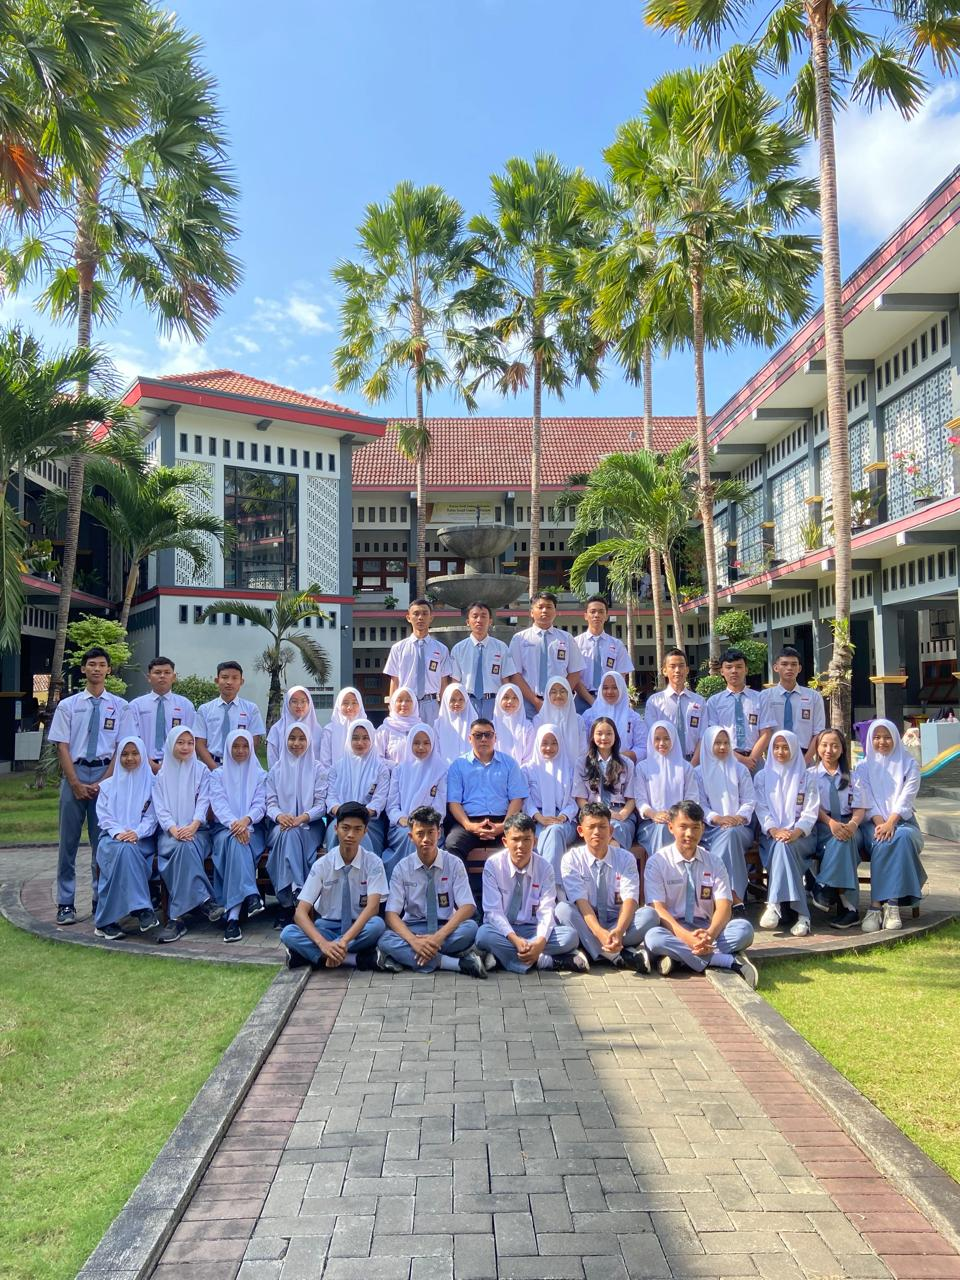

In [3]:
try:
    from google.colab import files

    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No image was uploaded.")

    source_path = Path(next(iter(uploaded)))

except ImportError:
    path_text = input("Enter the path to your photograph: ").strip()
    source_path = Path(path_text).expanduser()

if not source_path.is_file():
    raise FileNotFoundError(f"Image not found: {source_path}")

with Image.open(source_path) as image:
    original = ImageOps.exif_transpose(image).convert("RGB")

original.thumbnail((1600, 1600), Image.Resampling.LANCZOS)

reference_path = IMAGES / "reference.png"
original.save(reference_path)

print("Uploaded:", source_path.name)
print("Reference saved to:", reference_path)
print("Working image size:", original.size)
display(original)

## 3. Simulate Four Image Problems

Four independent degraded images are generated from the same reference:

| Condition | Simulation |
| --- | --- |
| Dark | Gamma correction that decreases image brightness |
| Bright | Gamma correction that increases image brightness |
| Low contrast | Compression of pixel values into a narrower intensity range |
| Blurred | Gaussian blur |

Each case starts from the reference image, rather than from another degraded image. This makes the four comparisons consistent.

In [4]:
def gamma_correct(image, gamma):
    lookup_table = [
        round(255 * (value / 255) ** gamma)
        for value in range(256)
    ]
    return image.point(lookup_table * 3)


pixels = np.asarray(original, dtype=np.float32)

degraded = {
    "dark": gamma_correct(original, gamma=1.55),
    "bright": gamma_correct(original, gamma=0.69),
    "low_contrast": Image.fromarray(
        np.uint8(np.clip(pixels * 0.52 + 61, 0, 255))
    ),
    "blurred": original.filter(
        ImageFilter.GaussianBlur(radius=1.5)
    ),
}

degraded_paths = []

for condition, image in degraded.items():
    path = IMAGES / f"{condition}_degraded.png"
    image.save(path)
    degraded_paths.append(path)
    print(f"{condition}: {path}")

dark: images/dark_degraded.png
bright: images/bright_degraded.png
low_contrast: images/low_contrast_degraded.png
blurred: images/blurred_degraded.png


## 4. Apply Image Enhancement

Each degraded image is processed with a method suited to its condition:

| Condition | Enhancement method |
| --- | --- |
| Dark | Gamma correction to brighten the image |
| Bright | Gamma correction to darken the image |
| Low contrast | Automatic contrast stretching |
| Blurred | Unsharp masking to strengthen visible edges |

Sharpening cannot reconstruct details that have been completely lost through blur. Similarly, brightness adjustment cannot recover information lost through severe clipping.

In [5]:
def enhance_dark(image):
    return gamma_correct(image, gamma=0.65)


def enhance_bright(image):
    return gamma_correct(image, gamma=1.45)


def enhance_low_contrast(image):
    return ImageOps.autocontrast(image, cutoff=1)


def enhance_blurred(image):
    return image.filter(
        ImageFilter.UnsharpMask(
            radius=1.5,
            percent=200,
            threshold=0
        )
    )


methods = {
    "dark": enhance_dark,
    "bright": enhance_bright,
    "low_contrast": enhance_low_contrast,
    "blurred": enhance_blurred,
}

enhanced = {}
enhanced_paths = []

for condition, method in methods.items():
    enhanced[condition] = method(degraded[condition])

    path = RESULTS / f"{condition}_enhanced.png"
    enhanced[condition].save(path)
    enhanced_paths.append(path)

    print(f"{condition}: {path}")

dark: results/dark_enhanced.png
bright: results/bright_enhanced.png
low_contrast: results/low_contrast_enhanced.png
blurred: results/blurred_enhanced.png


## 5. Visual Comparison

Each row below shows the same reference photograph, one degraded version, and its enhanced result. Compare the visibility of details, brightness, contrast, and sharpness. An enhancement may improve the numerical score while still introducing visible artifacts, so visual inspection remains necessary.

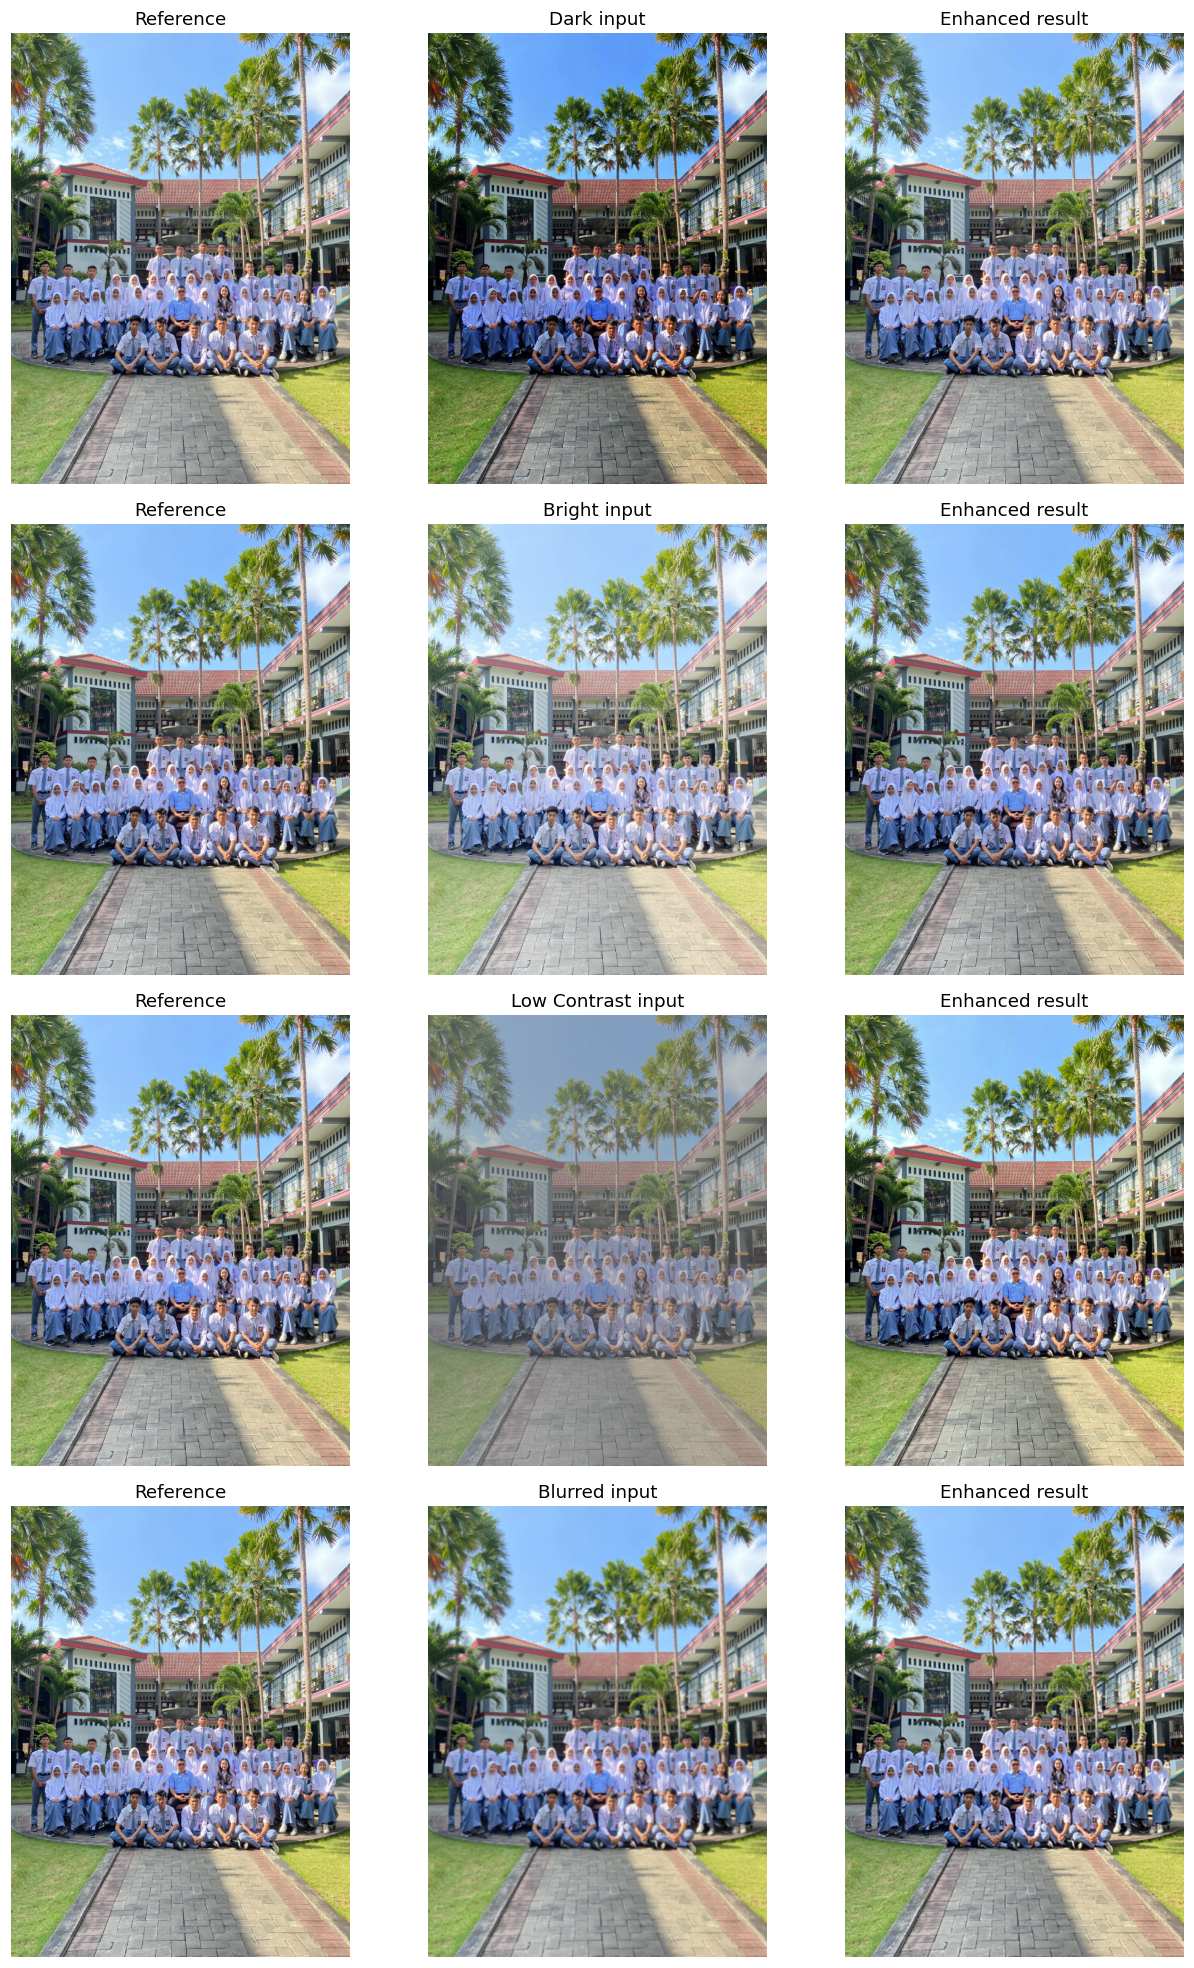

Comparison saved to: results/comparison.png


In [6]:
fig, axes = plt.subplots(4, 3, figsize=(12, 18), dpi=110)

for row, condition in enumerate(methods):
    images_to_show = [
        ("Reference", original),
        (f"{condition.replace('_', ' ').title()} input", degraded[condition]),
        ("Enhanced result", enhanced[condition]),
    ]

    for col, (title, image) in enumerate(images_to_show):
        axes[row, col].imshow(image)
        axes[row, col].set_title(title)
        axes[row, col].axis("off")

fig.tight_layout()

comparison_path = RESULTS / "comparison.png"
fig.savefig(comparison_path, bbox_inches="tight")
plt.show()

print("Comparison saved to:", comparison_path)

## 6. Quantitative Evaluation with PSNR

Peak Signal-to-Noise Ratio (PSNR) measures numerical similarity between an image and a reference. It is calculated from the Mean Squared Error (MSE):

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N}(I_i-K_i)^2
$$

$$
\mathrm{PSNR} = 10\log_{10}\left(\frac{255^2}{\mathrm{MSE}}\right)
$$

Here, \(I\) is the reference, \(K\) is the image being evaluated, and \(N\) is the number of values across all RGB pixels. A higher PSNR means greater numerical similarity to the reference. For each condition, the notebook calculates PSNR before and after enhancement.

In [7]:
def calculate_psnr(reference, image):
    reference_array = np.asarray(reference, dtype=np.float64)
    image_array = np.asarray(image, dtype=np.float64)

    if reference_array.shape != image_array.shape:
        raise ValueError("Images must have the same dimensions and channels.")

    mse = np.mean((reference_array - image_array) ** 2)

    if mse == 0:
        return float("inf")

    return float(10 * np.log10((255 ** 2) / mse))


rows = []

for condition in methods:
    before = calculate_psnr(original, degraded[condition])
    after = calculate_psnr(original, enhanced[condition])

    rows.append({
        "condition": condition,
        "psnr_before_db": round(before, 2),
        "psnr_after_db": round(after, 2),
        "change_db": round(after - before, 2),
    })

metrics_path = RESULTS / "psnr_results.csv"

with metrics_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print(f"{'Condition':<15} {'Before (dB)':>12} {'After (dB)':>12} {'Change (dB)':>13}")
print("-" * 56)

for row in rows:
    print(
        f"{row['condition']:<15}"
        f"{row['psnr_before_db']:>12.2f}"
        f"{row['psnr_after_db']:>12.2f}"
        f"{row['change_db']:>13.2f}"
    )

print("\nResults saved to:", metrics_path)

Condition        Before (dB)   After (dB)   Change (dB)
--------------------------------------------------------
dark                  17.80       50.76        32.95
bright                19.74       56.09        36.34
low_contrast          18.65       33.04        14.39
blurred               22.78       24.10         1.32

Results saved to: results/psnr_results.csv


## 7. Discussion and Conclusion

The four enhancement methods address different simulated problems. Gamma correction adjusts dark and overly bright images, automatic contrast stretching expands the intensity range of the low-contrast image, and unsharp masking strengthens edges in the blurred image.

Compare the PSNR values in the table above. A positive change means the enhanced image is numerically closer to the reference than the degraded input. The size of the improvement may differ among conditions. In particular, blur can remove fine detail that sharpening cannot fully restore.

Because the degraded images were generated from a known reference, this experiment allows quantitative evaluation. However, the results describe these controlled simulations and should not be treated as guaranteed improvements for arbitrary camera photographs.

## 8. Package the Outputs

The next cell packages the reference, four degraded images, four enhanced images, comparison figure, and PSNR table into a ZIP file.

In [8]:
bundle_path = Path("PCD_Assignment02_outputs.zip")

files_to_package = (
    [reference_path]
    + degraded_paths
    + enhanced_paths
    + [comparison_path, metrics_path]
)

with zipfile.ZipFile(
    bundle_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as bundle:
    for path in files_to_package:
        bundle.write(path, arcname=path.as_posix())

print("Created:", bundle_path)

try:
    from google.colab import files
    files.download(str(bundle_path))
except ImportError:
    print("Find the ZIP file in your notebook's working folder.")

Created: PCD_Assignment02_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>